# Введение
## Цель
Изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard. 
## Задачи
1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:
    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);
    - Деревья решений (Decision Tree);
    - Линейный дискриминантный анализ (Linear Discriminant Analysis);
    - Метод опорных векторов (Support Vector Machines);
    - Метод ближайших соседей (k-Nearest Neighbors);
2. Затем сравните качество работы классификаторов с помощью следующих метрик:
    - Accuracy (точность),
    - Precision (доля правильно классифицированных положительных примеров),
    - Recall (чувствительность, доля верно найденных положительных примеров),
    - F1-Score (среднее гармоническое precision и recall),
    - Площадь под кривой ROC (AUC-ROC).
3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.
4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

# Выбор и подготовка датасета
## Описание датасета
Для работы выбран датасет [Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset). 

Этот датасет содержит информацию о красных винах португальского региона "Винью Верде". Данные были собраны в результате физико-химических лабораторных тестов, а целевая переменная (качество) основана на сенсорной оценке (дегустации).
Признаки:
1. fixed acidity - титруемая кислотность
2. volatile acidity - летучая кислотность
3. citric acid - лимонная кислота
4. residual sugar - остаточный сахар
5. chlorides - хлориды
6. free sulfur dioxide - свободный диоксид серы
7. total sulfur dioxide - общий диоксид серы
8. density - плотность
9. pH - водородный показатель
10. sulphates - сульфаты
11. alcohol - алкоголь (в %)
12. quality - качество (от 0 до 10)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sb
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import scipy.stats as stats

file_path = "WineQT.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
)

df = df.drop(columns=["Id"])
display(df.head())

c:\Users\bulch\Desktop\Нейронки\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 76.2k/76.2k [00:00<00:00, 328kB/s]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Анализ параметров

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Титруемая кислотность (fixed acidity),8.31,7.90,7.20,4.60,15.90,1.75,3.05,1.04,1.38,"{0.25: 7.1, 0.5: 7.9, 0.75: 9.1}",p=4.679e-12 → Далеко от нормального
1,Летучая кислотность (volatile acidity),0.53,0.52,0.50,0.12,1.58,0.18,0.03,0.68,1.38,"{0.25: 0.3925, 0.5: 0.52, 0.75: 0.64}",p=5.665e-03 → Далеко от нормального
2,Лимонная кислота (citric acid),0.27,0.25,0.00,0.00,1.00,0.20,0.04,0.37,-0.71,"{0.25: 0.09, 0.5: 0.25, 0.75: 0.42}",p=7.683e-08 → Далеко от нормального
3,Остаточный сахар (residual sugar),2.53,2.20,2.00,0.90,15.50,1.36,1.84,4.36,27.68,"{0.25: 1.9, 0.5: 2.2, 0.75: 2.6}",p=5.887e-68 → Далеко от нормального
4,Хлориды (chlorides),0.09,0.08,0.08,0.01,0.61,0.05,0.00,6.03,47.08,"{0.25: 0.07, 0.5: 0.079, 0.75: 0.09}",p=1.097e-67 → Далеко от нормального
5,Свободный диоксид серы (free sulfur dioxide),15.62,13.00,6.00,1.00,68.00,10.25,105.07,1.23,1.93,"{0.25: 7.0, 0.5: 13.0, 0.75: 21.0}",p=1.948e-12 → Далеко от нормального
6,Общий диоксид серы (total sulfur dioxide),45.91,37.00,28.00,6.00,289.00,32.78,1074.67,1.67,5.10,"{0.25: 21.0, 0.5: 37.0, 0.75: 61.0}",p=4.584e-15 → Далеко от нормального
7,Плотность (density),1.00,1.00,1.00,0.99,1.00,0.00,0.00,0.10,0.89,"{0.25: 0.99557, 0.5: 0.99668, 0.75: 0.997845}",p=2.312e-02 → Близко к нормальному
8,Водородный показатель (pH),3.31,3.31,3.30,2.74,4.01,0.16,0.02,0.22,0.93,"{0.25: 3.205, 0.5: 3.31, 0.75: 3.4}",p=1.425e-02 → Близко к нормальному
9,Сульфаты (sulphates),0.66,0.62,0.60,0.33,2.00,0.17,0.03,2.50,12.02,"{0.25: 0.55, 0.5: 0.62, 0.75: 0.73}",p=2.989e-17 → Далеко от нормального


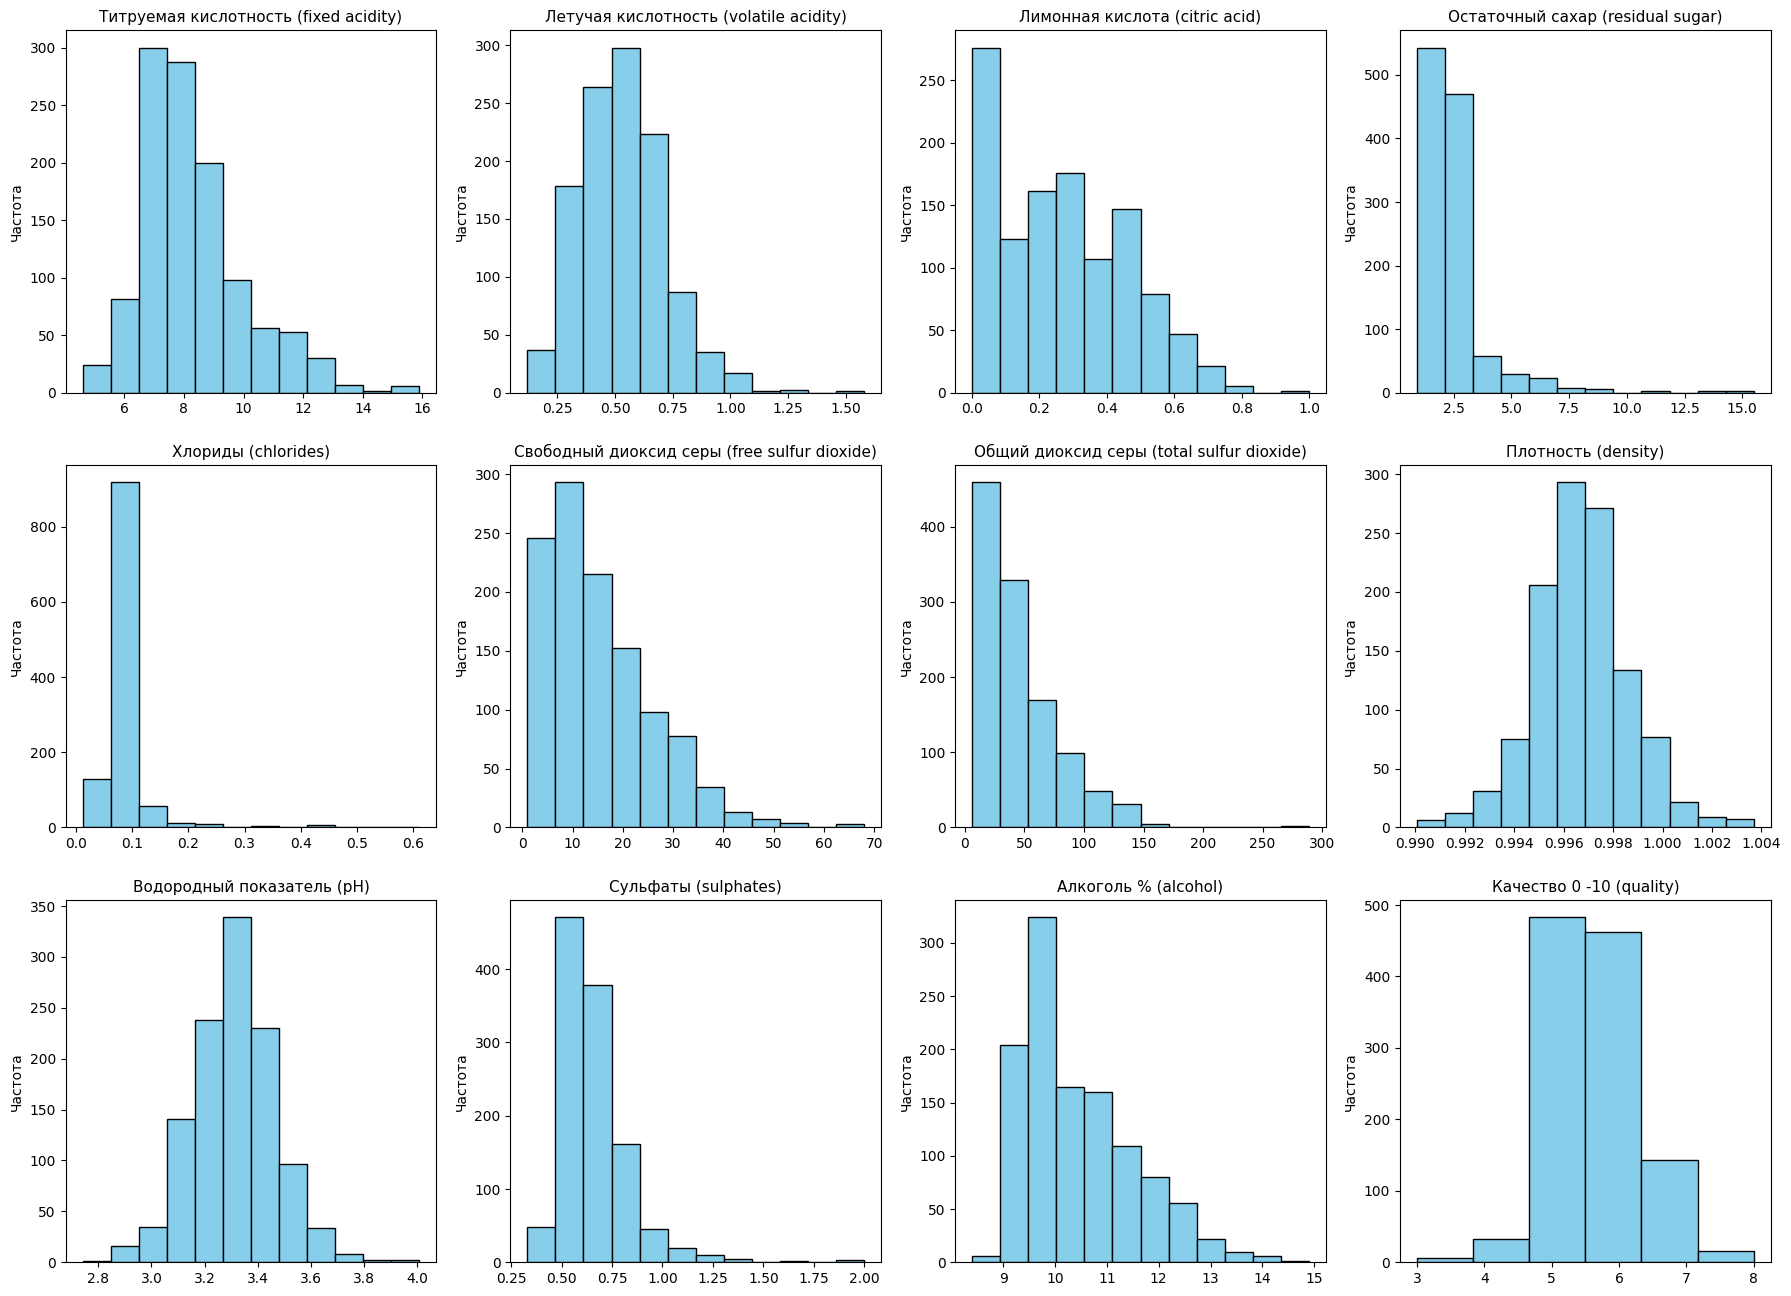

In [2]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
translate = {
    "fixed acidity" : "Титруемая кислотность (fixed acidity)",
    "volatile acidity" : "Летучая кислотность (volatile acidity)",
    "citric acid" : "Лимонная кислота (citric acid)",
    "residual sugar" : "Остаточный сахар (residual sugar)",
    "chlorides" : "Хлориды (chlorides)",
    "free sulfur dioxide" : "Свободный диоксид серы (free sulfur dioxide)",
    "total sulfur dioxide" : "Общий диоксид серы (total sulfur dioxide)",
    "density" : "Плотность (density)",
    "pH" : "Водородный показатель (pH)",
    "sulphates" : "Сульфаты (sulphates)",
    "alcohol" : "Алкоголь % (alcohol)",
    "quality" : "Качество 0 -10 (quality)"
}

features = df.columns
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [], "Квантили (25%, 50%, 75%)": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    stat["Признак"].append(translate[feature])
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Квантили (25%, 50%, 75%)"].append(df[feature].quantile([0.25, 0.5, 0.75]).to_dict())
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    k_ = k if feature != "quality" else 6
    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(translate[feature], fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

Отсюда видна большая проблема - у quality очень маленькая частота для 3. Поменяем качество 3 -> 4, а так же приведем к 5-бальной шкале (от 1 до 5).

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Качество 1-5 (quality),2.66,3.0,2,1,5,0.79,0.63,0.43,-0.02,"{0.25: 2.0, 0.5: 3.0, 0.75: 3.0}",p=3.651e-66 → Далеко от нормального


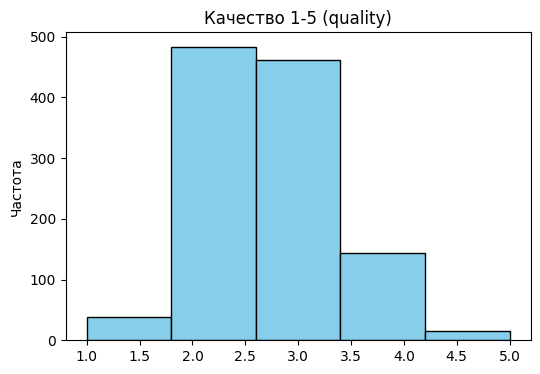

In [3]:
y = df['quality'].map({3: 1, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5})
df['quality'] = y

translate['quality'] = "Качество 1-5 (quality)"
feature = 'quality'
ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

stat = {
    "Признак": translate[feature],
    "Среднее": round(df[feature].mean(), 2),
    "Медиана": round(df[feature].median(), 2),
    "Мода": round(df[feature].mode()[0], 2),
    "Минимум": round(df[feature].min(), 2),
    "Максимум": round(df[feature].max(), 2),
    "Стандартное отклонение": round(df[feature].std(), 2),
    "Дисперсия": round(df[feature].var(), 2),
    "Асимметрия": round(df[feature].skew(), 2),
    "Эксцесс": round(df[feature].kurtosis(), 2),
    "Квантили (25%, 50%, 75%)": df[feature].quantile([0.25, 0.5, 0.75]).to_dict(),
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}"
}

# Вывод таблицы
display(pd.DataFrame([stat]))

# Гистограмма
plt.figure(figsize=(6,4))
plt.hist(df[feature], bins=5, edgecolor='black', color='skyblue')
plt.title(translate[feature])
plt.ylabel('Частота')
plt.show()


# Разбиение выборки

In [4]:
X = df.drop(columns=["quality"])
y = df["quality"]  

# Разбиение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Стандартизированный вариант
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Методы классификации

## Функция для вывода метрик

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def get_metrics(y_true, y_pred, y_score, class_names=None):
    classes = np.unique(y_true)
    names  = class_names or [str(c) for c in classes]
    avgs   = ['micro','macro','weighted']
    acc    = accuracy_score(y_true, y_pred)

    p_c, r_c, f_c, _ = precision_recall_fscore_support(y_true, y_pred, labels=classes, average=None, zero_division=0)
    y_bin  = label_binarize(y_true, classes=classes)
    auc_c  = [roc_auc_score(y_bin[:, i], y_score[:, i]) for i in range(len(classes))]

    cols = ['Precision','Recall','F1','Accuracy','ROC AUC']
    df_classes = pd.DataFrame(np.column_stack([p_c, r_c, f_c, np.full_like(p_c, np.nan), auc_c]), index=names, columns=cols)
    df_aggs = pd.DataFrame([[*precision_recall_fscore_support(y_true, y_pred, average=a, zero_division=0)[:3],
                              acc, roc_auc_score(y_true, y_score, multi_class='ovr', average=a)] for a in avgs],
                           index=avgs, columns=cols)

    df = pd.concat([df_classes, df_aggs])
    for c in ['Precision','Recall','F1','ROC AUC']:
        df[c] = df[c].astype(float).round(4)

    df['Accuracy'] = df['Accuracy'].astype('object')
    df.loc[names, 'Accuracy'] = ''                                
    df.loc[avgs,  'Accuracy'] = df.loc[avgs, 'Accuracy'].astype(float).round(4)
    display(df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=classes), display_labels=names)\
        .plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Матрица ошибок')

    for i, name in enumerate(names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        axes[1].plot(fpr, tpr, lw=2, label=name)
    axes[1].plot([0,1],[0,1],'--', lw=1)
    axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC (OvR)')
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return df


## 1.Наивный Байесовский классификатор

Есть 4 разновидности этого метода
- GaussianNB - непрерывные (вещественные) признаки,
- MultinomialNB - счётчики (тексты), целые числа,
- ComplementNB - тоже счётчики, но с фокусом на дисбаланс (модификация Multinomial),
- BernoulliNB - бинарные признаки (0/1).
Так как у нас вещественные числа, то единственным подходящим вариантом становится GaussianNB.

Как работает:
В основе алгоритма лежит формула Байеса

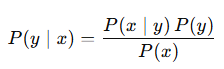

Метод предполагает, что все признаки независимы друг от друга при фиксированном классе:

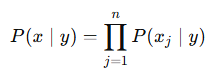

Обучение:
1. Считаем априорную вероятность класса

    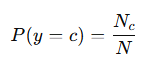

2. Считаем среднее и дисперсию

    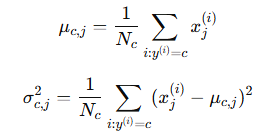

    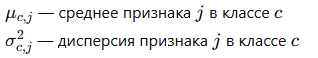


3. Считаем дисперсию с учетом сглаживания

    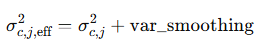




Предсказание:
1. Вычисляем плотность нормального распределения:

    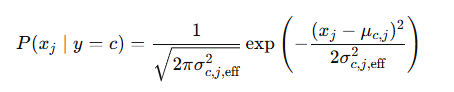
2. Вычисляем score

    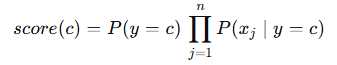

3. Выбираем класс с максимальным score



### Подбор лучших параметров
Будем перебирать признак var_smoothing - добавочная дисперсия

,var_smoothing,accuracy
0,0.000000e+00,0.565598
1,1.000000e-15,0.565598
2,1.000000e-14,0.565598
3,1.000000e-13,0.565598
4,1.000000e-12,0.565598
5,1.000000e-11,0.565598
6,1.000000e-10,0.565598
7,1.000000e-09,0.565598
8,1.000000e-08,0.565598
9,1.000000e-07,0.565598


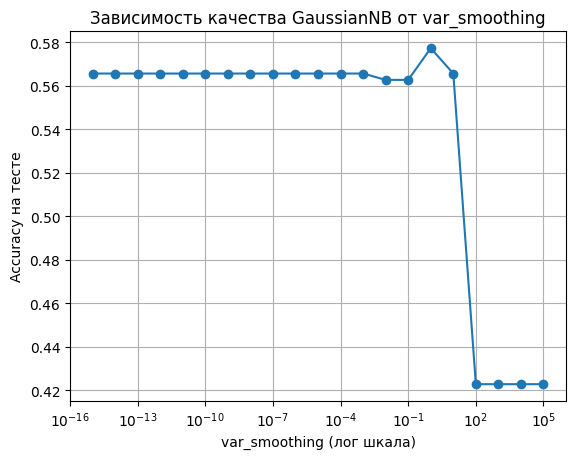

In [6]:
from sklearn.naive_bayes import GaussianNB

vs_values = np.concatenate([
    [0.0],
    np.logspace(-15, -1, 15),
    np.logspace(0, 5, 6)
])

results = []

for vs in vs_values:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results.append({
        "var_smoothing": vs,
        "accuracy": acc
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="var_smoothing")
    .reset_index(drop=True)
)

display(results_df)

mask_pos = results_df["var_smoothing"] > 0 
plt.figure()
plt.semilogx(
    results_df.loc[mask_pos, "var_smoothing"],
    results_df.loc[mask_pos, "accuracy"],
    marker="o"
)
plt.xlabel("var_smoothing (лог шкала)")
plt.ylabel("Accuracy на тесте")
plt.title("Зависимость качества GaussianNB от var_smoothing")
plt.grid(True)
plt.show()


- При малых значениях (0…1e-4) качество классификации остаётся постоянным (accuracy ≈ 0.5656).
Это означает, что исходные дисперсии достаточно большие, и добавляемое сглаживание практически не влияет на модель.

- При значениях 1e-2…1e-1 наблюдается небольшое снижение точности.
Это связано с тем, что распределения становятся шире, и модель хуже разделяет классы.

- Оптимальное значение — var_smoothing = 1,
при котором достигается максимальная точность accuracy = 0.5773.

- При больших значениях (1e2…1e5) качество резко падает (accuracy ≈ 0.4227).
В этом диапазоне сглаживание становится чрезмерным, распределения разных классов становятся почти одинаковыми, и модель теряет информативность признаков.

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.3333,0.0833,0.1333,,0.6767
2,0.6395,0.7586,0.6940,,0.7858
3,0.5419,0.6087,0.5734,,0.6794
4,0.2308,0.0698,0.1071,,0.8450
5,0.0000,0.0000,0.0000,,0.8746
micro,0.5773,0.5773,0.5773,0.5773,0.8626
macro,0.3491,0.3041,0.3016,0.5773,0.7723
weighted,0.5290,0.5773,0.5422,0.5773,0.7479


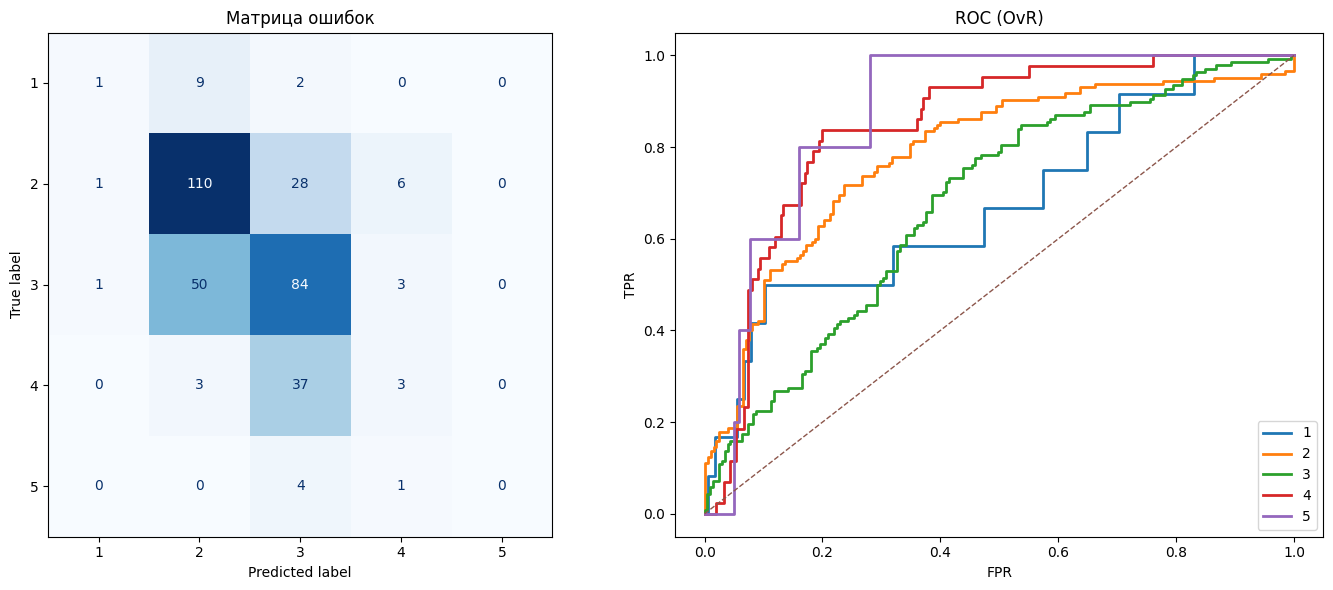

In [7]:
clf = GaussianNB(var_smoothing=1)
clf.fit(X_train_scaled, y_train)  

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

nb_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

Видим что модель дает низкую точность, и для решения наших задач не очень подходит. Вероятно это из-за того что алгоритм требует нормальное распредление - что у нас не соблюдено.

## 2. Дерево решений

Как строится дерево:
1. Считаем значение критерия в узле. Среди кретериев используется Gini и Entropy:

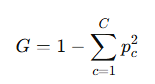
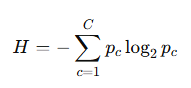

2. Составляется список правил по типу <значение> <= <параметр>.
3. Для каждого правило считается качество разделения 

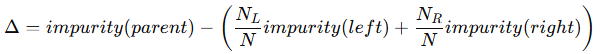

(impurity - выбранный критерий)

4. Выбираем правило с наибольшим качеством разделения, составляем 2 новых узлы и для каждого повторяем действия 1 - 4.
5. Остановка происходит: 
    - в момент, когда impurity на узле = 0 (это значит что в узле все принадлежит одному классу) 
    - достигили max_depth - максимальной глубины дерева.
    - в узле слишком мало объектов, т.е. <количество_объектов> < min_samples_split (2 по умолчанию)
    - если при разбиении будет создан узел в котором будет меньше оббъектов чем указано в min_samples_leaf
    - невозможно улучшить критерий Gini/Entropy


### Подбор лучших параметров
Будем перебирать следующие критерии:
- criterion — критерий качества разбиения (gini/entropy)
- max_depth — максимальная глубина дерева

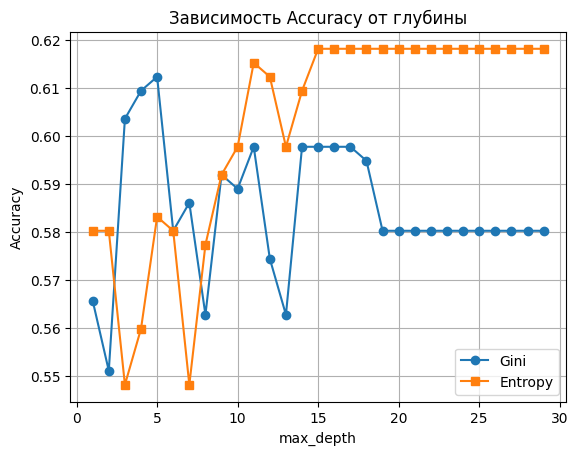

In [8]:
from sklearn.tree import DecisionTreeClassifier

depth_values = list(range(1, 30))

acc_gini = []
acc_entropy = []

for depth in depth_values:
    clf_gini = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    clf_gini.fit(X_train, y_train)
    y_pred_gini = clf_gini.predict(X_test)
    acc_gini.append(accuracy_score(y_test, y_pred_gini))

    clf_entropy = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    clf_entropy.fit(X_train, y_train)
    y_pred_entropy = clf_entropy.predict(X_test)
    acc_entropy.append(accuracy_score(y_test, y_pred_entropy))

# График
plt.figure()
plt.plot(depth_values, acc_gini, marker="o", label="Gini")
plt.plot(depth_values, acc_entropy, marker="s", label="Entropy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Зависимость Accuracy от глубины")
plt.grid(True)
plt.legend()
plt.show()

Мы видим что для энтропии с 15 дерево никак не меняется, у джини с 19. У джини после 5 резко ухудшается качество, можно сказать что модель начинает переобучаться. У энтропии это начинается с 11. Лучшим решением будет взять gini и max_depth = 5/

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.0000,0.0000,0.0000,,0.5228
2,0.6494,0.7793,0.7085,,0.7734
3,0.5755,0.5797,0.5776,,0.6705
4,0.5667,0.3953,0.4658,,0.8416
5,0.0000,0.0000,0.0000,,0.8956
micro,0.6122,0.6122,0.6122,0.6122,0.8643
macro,0.3583,0.3509,0.3504,0.6122,0.7408
weighted,0.5771,0.6122,0.5903,0.6122,0.7336


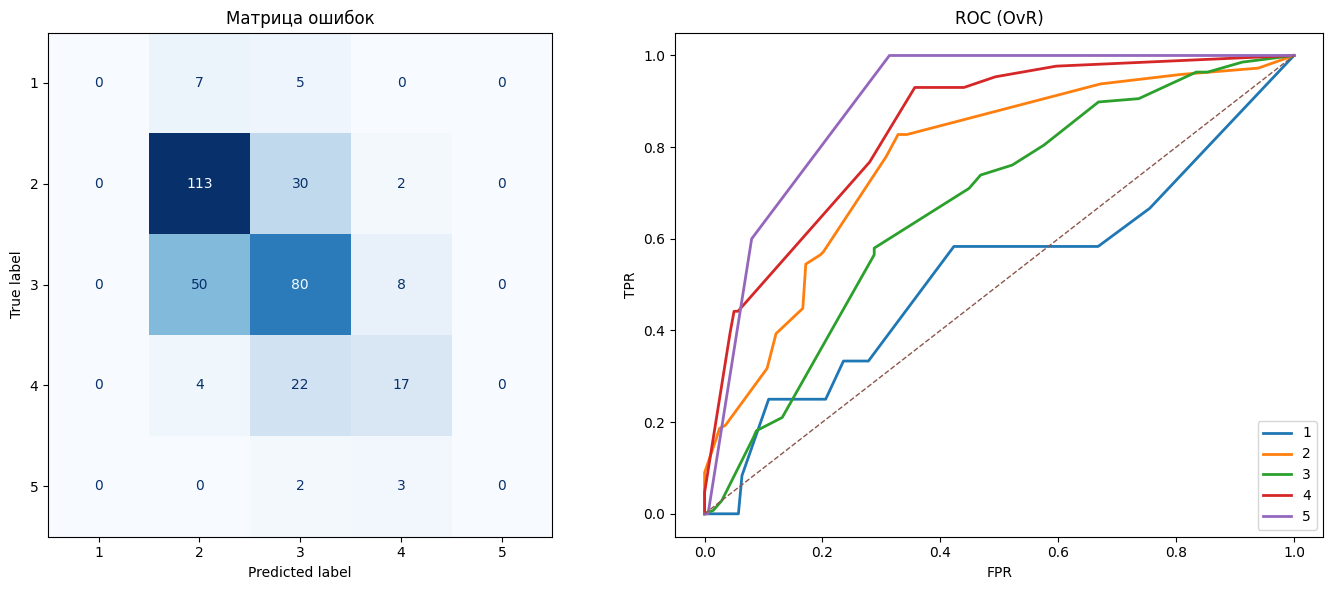

In [9]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

tree_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

### Визуализация дерева решения

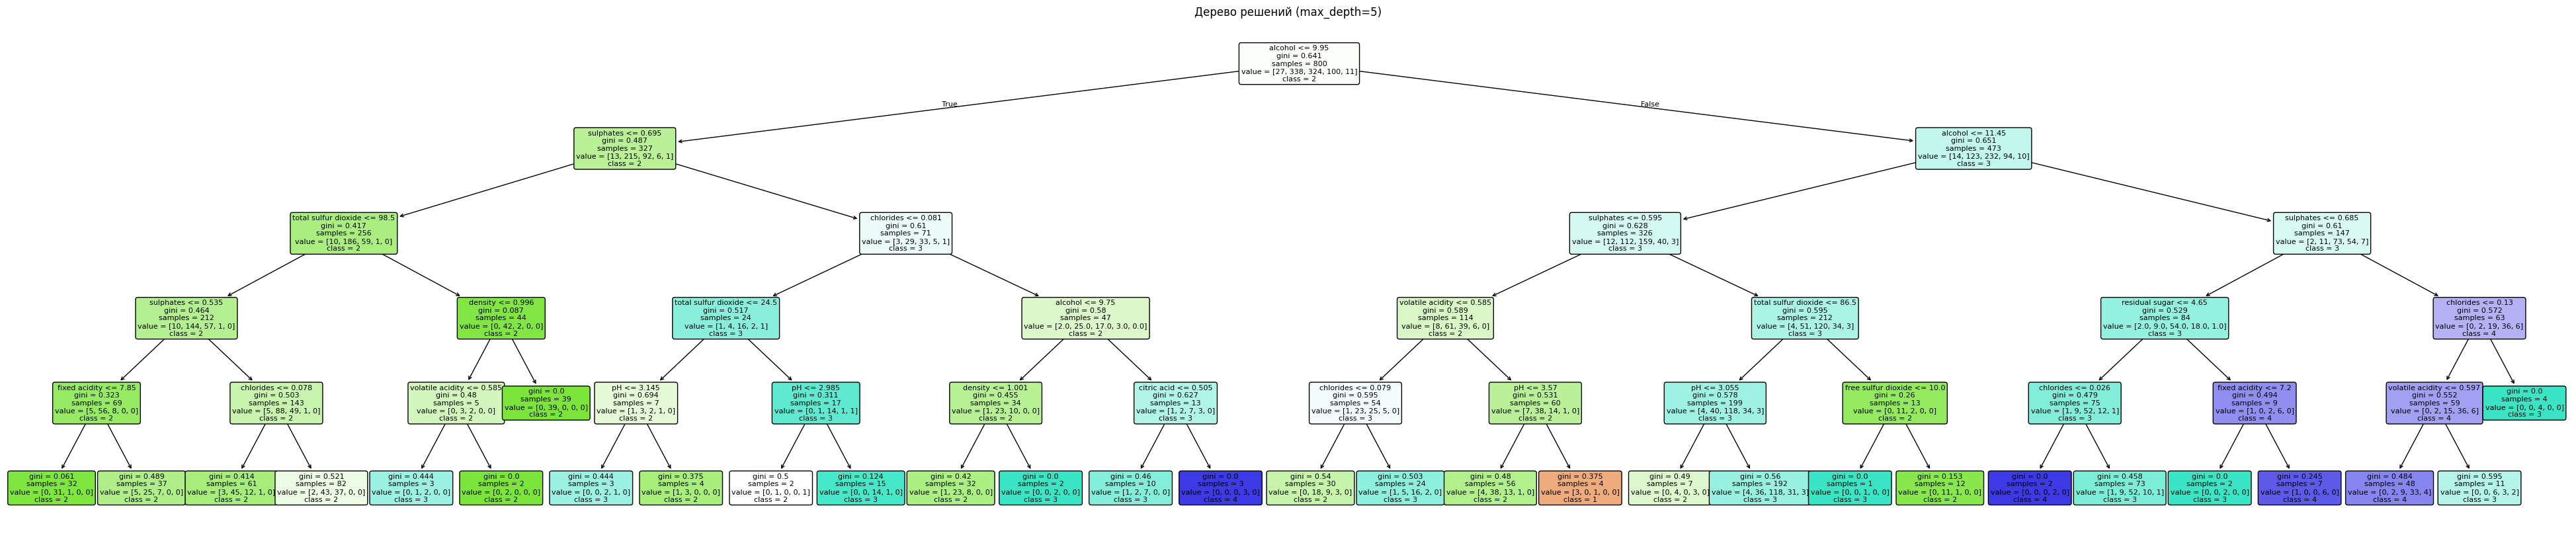

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(50, 10))  

plot_tree(
    clf,
    feature_names=X.columns,              
    class_names=['1', '2', '3', '4', '5'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Дерево решений (max_depth=5)")
plt.show()

## 3. Линейный дискриминантный анализ

Идея: Найти такое направление (прямую/плоскость), вдоль которого классы лучше всего отделяются, а внутри каждого класса разброс минимален.

Обучение:
1. Вычисляем средний вектор класса

    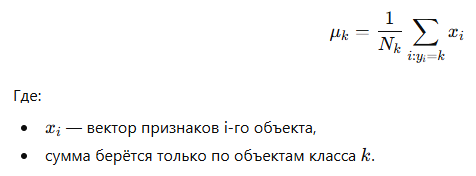

2. Считаем «смешанную» ковариацию по всем классам:

    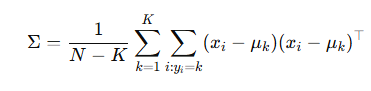

3. Считаем априорные вероятности классов

    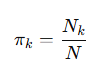

4. Для каждого класса строится функция

    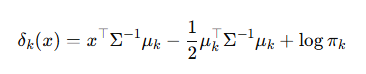

Предсказание:

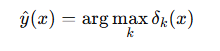

По сути подставляем в каждую функцию наши параметры - где больше, тот класс и берем.
Геометрически это означает: границы между классами – гиперплоскости (линейные границы).

### Подбор лучших параметров

Будем исследовать следующие параметры:
1. solver - метод решения
    - svd - по умолчанию
    - lsqr - метод наименьших квадратов
    - eigen - собственные значения/векторы
2. n_components - сколько линейных дискриминантных компонент использовать
3. shrinkage - регуляризация ковариационной матрицы
    - None - без регуляризации, чистая оценка ковариации.
    - auto - автоматический подбор
    - от 0 до 1

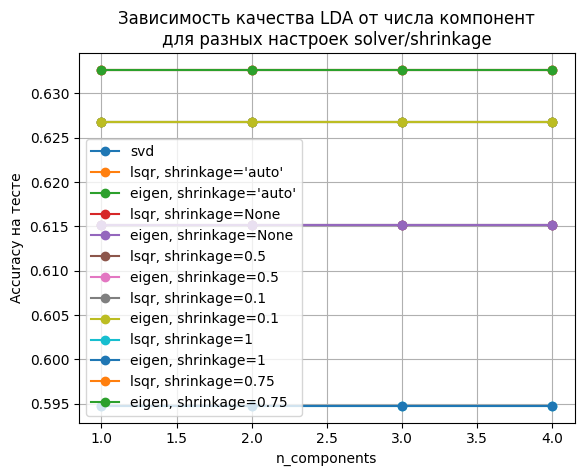

Лучший результат: config=lsqr+0.5, n_components=4, accuracy=0.6327


In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_train))
max_components = min(n_features, n_classes - 1)

components_range = range(1, max_components + 1)

configs = [
    ("svd",   {"solver": "svd",  "shrinkage": None},          "svd"),
    ("lsqr+auto", {"solver": "lsqr", "shrinkage": "auto"},    "lsqr, shrinkage='auto'"),
    ("eigen+auto", {"solver": "eigen", "shrinkage": "auto"},    "eigen, shrinkage='auto'"),
    ("lsqr+None", {"solver": "lsqr", "shrinkage": None},    "lsqr, shrinkage=None"),
    ("eigen+None", {"solver": "eigen", "shrinkage": None},    "eigen, shrinkage=None"),
    ("lsqr+0.5", {"solver": "lsqr", "shrinkage": 0.5},    "lsqr, shrinkage=0.5"),
    ("eigen+0.5", {"solver": "eigen", "shrinkage": 0.5},    "eigen, shrinkage=0.5"),
    ("lsqr+0.1", {"solver": "lsqr", "shrinkage": 0.1},    "lsqr, shrinkage=0.1"),
    ("eigen+0.1", {"solver": "eigen", "shrinkage": 0.1},    "eigen, shrinkage=0.1"),
    ("lsqr+1", {"solver": "lsqr", "shrinkage": 1},    "lsqr, shrinkage=1"),
    ("eigen+1", {"solver": "eigen", "shrinkage": 1},    "eigen, shrinkage=1"),
    ("lsqr+0.75", {"solver": "lsqr", "shrinkage": 0.75},    "lsqr, shrinkage=0.75"),
    ("eigen+0.75", {"solver": "eigen", "shrinkage": 0.75},    "eigen, shrinkage=0.75"),

]

results = []

plt.figure()

for label, params, legend_label in configs:
    acc_list = []
    for n_comp in components_range:
        lda = LinearDiscriminantAnalysis(
            solver=params["solver"],
            shrinkage=params["shrinkage"],
            n_components=n_comp
        )
        lda.fit(X_train_scaled, y_train)
        y_pred = lda.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        acc_list.append(acc)

        results.append({
            "config": label,
            "n_components": n_comp,
            "accuracy": acc
        })

    plt.plot(list(components_range), acc_list, marker="o", label=legend_label)

plt.xlabel("n_components")
plt.ylabel("Accuracy на тесте")
plt.title("Зависимость качества LDA от числа компонент\nдля разных настроек solver/shrinkage")
plt.grid(True)
plt.legend()
plt.show()

results_df = pd.DataFrame(results)
best_row = results_df.sort_values("accuracy", ascending=False).iloc[0]
print(
    "Лучший результат:",
    f"config={best_row['config']},",
    f"n_components={best_row['n_components']},",
    f"accuracy={best_row['accuracy']:.4f}"
)

Видим что многие вариации дают одинаковый результат. При этом n_components вообще никак не влияют. Исследуем только solver и shrinkage


Лучший результат: solver=lsqr, shrinkage=0.3469387755102041, accuracy=0.6385


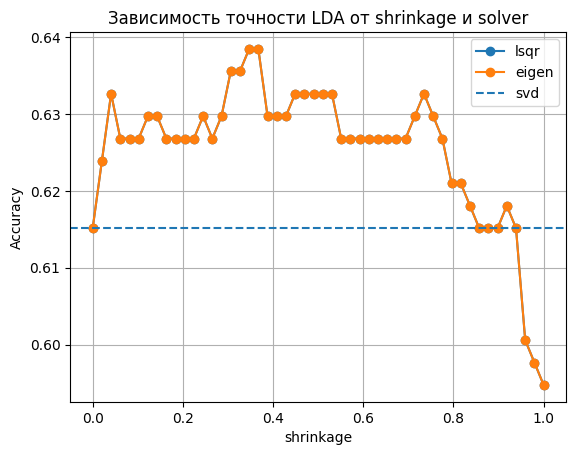

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

solvers = ["svd", "lsqr", "eigen"]
shrinkage_values = [None, "auto"] + list(np.linspace(0.0, 1.0, 50))
results = []

for solver in solvers:
    for sh in shrinkage_values:
        if solver == "svd" and sh is not None:
            continue

        lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=sh)
        lda.fit(X_train_scaled, y_train)
        y_pred = lda.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        results.append({"solver": solver, "shrinkage": sh, "accuracy": acc})

results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df["accuracy"].idxmax()]
print(
    "\nЛучший результат:",
    f"solver={best_row['solver']},",
    f"shrinkage={best_row['shrinkage']},",
    f"accuracy={best_row['accuracy']:.4f}",
)

numeric_mask = pd.to_numeric(results_df["shrinkage"], errors="coerce").notna()

plt.figure()

for solver in ["lsqr", "eigen"]:
    df_s = results_df[(results_df["solver"] == solver) & numeric_mask]
    plt.plot(df_s["shrinkage"], df_s["accuracy"], marker="o", label=solver)

svd_acc = results_df[results_df["solver"] == "svd"]["accuracy"].iloc[0]
plt.axhline(y=svd_acc, linestyle="--", label="svd")

plt.xlabel("shrinkage")
plt.ylabel("Accuracy")
plt.title("Зависимость точности LDA от shrinkage и solver")
plt.grid(True)
plt.legend()
plt.show()


В общем видим что lsqr и eigen между собой не имеют отличий. svd дает результат хуже.

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.6667,0.1667,0.2667,,0.6684
2,0.6864,0.8000,0.7389,,0.8217
3,0.6220,0.5725,0.5962,,0.7204
4,0.5000,0.5116,0.5057,,0.8672
5,0.0000,0.0000,0.0000,,0.8947
micro,0.6385,0.6385,0.6385,0.6385,0.8901
macro,0.4950,0.4102,0.4215,0.6385,0.7945
weighted,0.6264,0.6385,0.6250,0.6385,0.7824


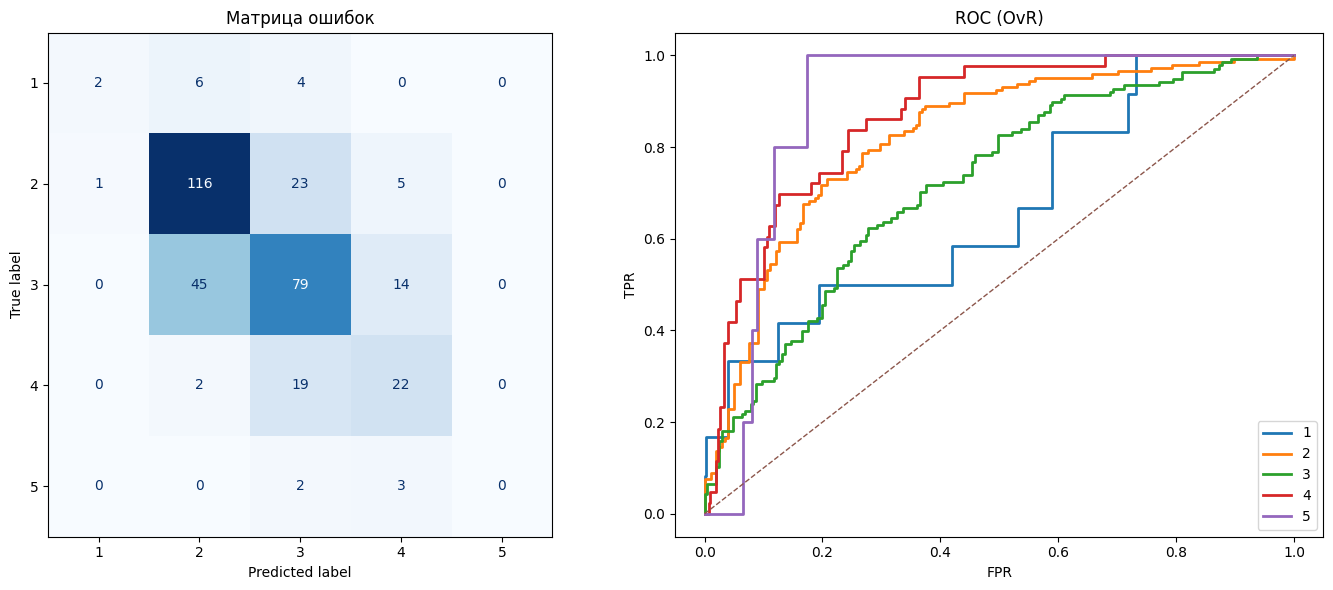

In [13]:
clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.35)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

lda_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

## 4. Метод опорных векторов

### Подбор лучших параметров

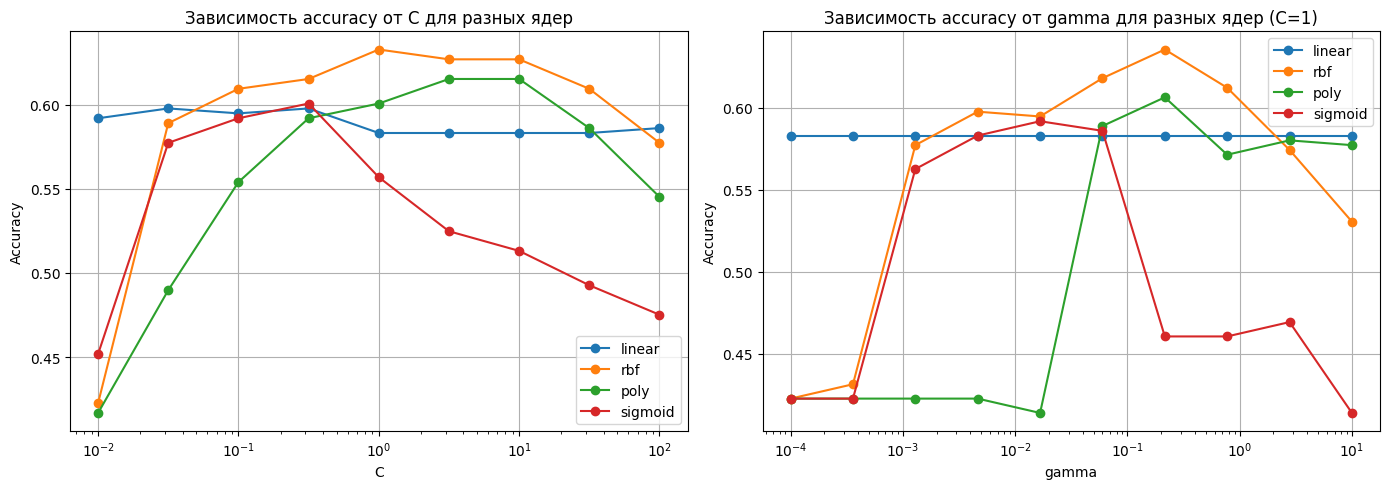


Лучший результат: kernel=rbf, C=1.0, gamma=0.21544346900318845, accuracy=0.6356


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

kernels = ["linear", "rbf", "poly", "sigmoid"]

C_values = np.logspace(-2, 2, 9)      # 0.01 .. 100
gamma_values = np.logspace(-4, 1, 10) # 1e-4 .. 10

fig, (axC, axG) = plt.subplots(1, 2, figsize=(14, 5))

results = []  # здесь будем копить все проверенные комбинации

# --- График: accuracy от C для разных ядер ---
for kernel in kernels:
    acc_list = []
    for C in C_values:
        clf = SVC(kernel=kernel, C=C, gamma="scale")
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        acc_list.append(acc)

        results.append({
            "kernel": kernel,
            "C": C,
            "gamma": "scale",   # в этом цикле gamma всегда "scale"
            "mode": "C_sweep",
            "accuracy": acc
        })

    axC.semilogx(C_values, acc_list, marker="o", label=kernel)

axC.set_xlabel("C")
axC.set_ylabel("Accuracy")
axC.set_title("Зависимость accuracy от C для разных ядер")
axC.grid(True)
axC.legend()

# --- График: accuracy от gamma для разных ядер ---
for kernel in kernels:
    acc_list = []
    if kernel == "linear":
        # для линейного ядра gamma не используется, рисуем прямую
        clf = SVC(kernel="linear", C=1.0, gamma="scale")
        clf.fit(X_train_scaled, y_train)
        base_acc = accuracy_score(y_test, clf.predict(X_test_scaled))

        for g in gamma_values:
            acc_list.append(base_acc)
            results.append({
                "kernel": kernel,
                "C": 1.0,
                "gamma": g,
                "mode": "gamma_sweep",
                "accuracy": base_acc
            })
    else:
        for g in gamma_values:
            clf = SVC(kernel=kernel, C=1.0, gamma=g)
            clf.fit(X_train_scaled, y_train)
            y_pred = clf.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            acc_list.append(acc)

            results.append({
                "kernel": kernel,
                "C": 1.0,
                "gamma": g,
                "mode": "gamma_sweep",
                "accuracy": acc
            })

    axG.semilogx(gamma_values, acc_list, marker="o", label=kernel)

axG.set_xlabel("gamma")
axG.set_ylabel("Accuracy")
axG.set_title("Зависимость accuracy от gamma для разных ядер (C=1)")
axG.grid(True)
axG.legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
display(results_df)
best_row = results_df.sort_values("accuracy", ascending=False).iloc[0]
print(
    "\nЛучший результат:",
    f"kernel={best_row['kernel']},",
    f"C={best_row['C']},",
    f"gamma={best_row['gamma']},",
    f"accuracy={best_row['accuracy']:.4f}"
)


### Решение задачи классификации

## 5. Метод ближайших соседей

У метода нет как такого этапа построения. Идея метода - находим k ближайших соседий, и к какому классу принадлежат, тот и будет определен.
1. Считаем расстояние от нового объекта до всех точек в обучающей выборке. Есть несколько формул для растояние:
    - Евклидово расстояние (Euclidean):

    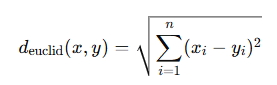
    - Манхэттенское расстояние (Manhattan)

    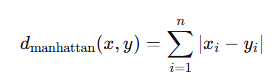
    - Общее расстояние Минковского (Minkowski)

    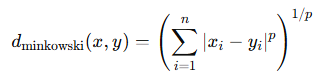
    - Расстояние Чебышёва (Chebyshev)

    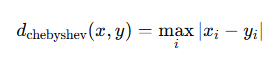


2. Выбираем k ближайших соседей. Сортируем расстояния, берём первые k точек.
3. Голосование соседей. Смотрим, к каким классам относятся эти k соседей. Если нет какого-то преобладающего класса, то можно использовать веса соседей (по сути брать с наименьшим растоянием) или брать наименьшую метку класса.



### Подбор лучших параметров
Будем перебирать 
- k - количество соседий
- metric - формула для растояния
- weights - distance - учитывыть веса / uniform - брать класс с наименьшим значением


(Стоит отметить что Manhattan = Minkowski p=1, а Euclidean = Minkowski p=2)


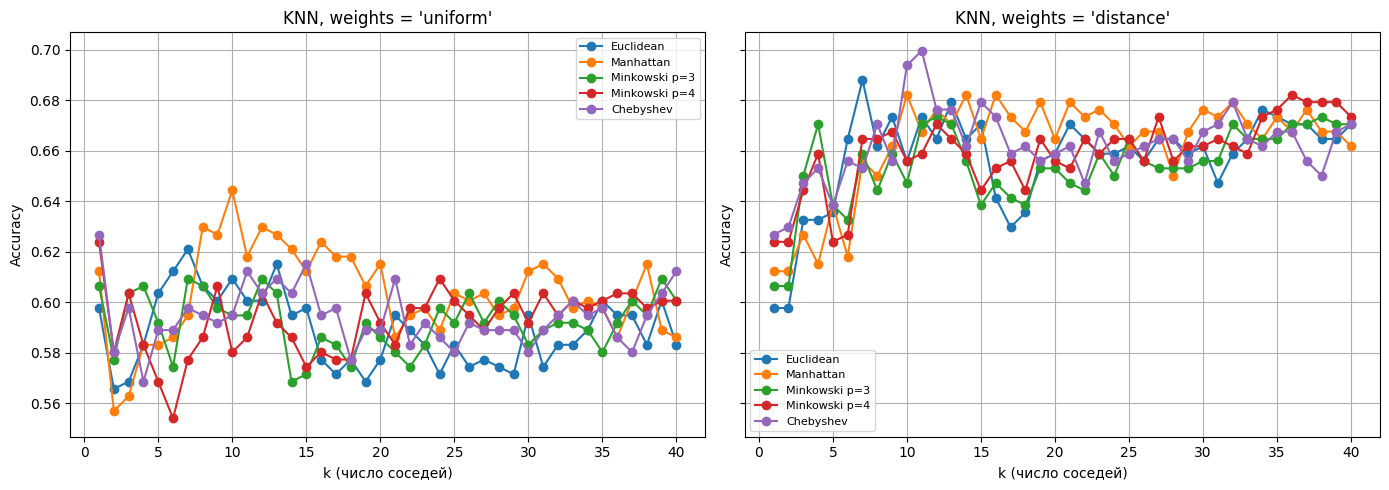


Лучший результат: weights=distance, metric=Chebyshev, k=11, accuracy=0.6997


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 41)  

metrics_config = [
    ("Euclidean",      {"metric": "euclidean"}),                
    ("Manhattan",      {"metric": "manhattan"}),                
    ("Minkowski p=3",  {"metric": "minkowski", "p": 3}),
    ("Minkowski p=4",  {"metric": "minkowski", "p": 4}),
    ("Chebyshev",      {"metric": "chebyshev"}),
]

all_results = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, weights in zip(axes, ["uniform", "distance"]):
    for label, params in metrics_config:
        acc_list = []

        for k in k_values:
            clf_knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=weights,                         
                metric=params["metric"],
                p=params.get("p", 2)                    
            )
            clf_knn.fit(X_train_scaled, y_train)
            y_pred = clf_knn.predict(X_test_scaled)
            acc = accuracy_score(y_test, y_pred)
            acc_list.append(acc)

            all_results.append({
                "weights": weights,
                "metric": label,
                "k": k,
                "accuracy": acc
            })

        ax.plot(list(k_values), acc_list, marker="o", label=label)

    ax.set_xlabel("k (число соседей)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"KNN, weights = '{weights}'")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

best_row = pd.DataFrame(all_results).sort_values("accuracy", ascending=False).iloc[0]
print(
    "\nЛучший результат:",
    f"weights={best_row['weights']},",
    f"metric={best_row['metric']},",
    f"k={best_row['k']},",
    f"accuracy={best_row['accuracy']:.4f}"
)


В целом видим что выбор кандитанов по весам, нежеле с наименьшей меткой, сильно повышает качество для всех метрик и k.
Где-то с 5-10 начинается переобучение, и качество несколько падает. Самым эффективными оказались параметры weights=distance, metric=Chebyshev, k=11.

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.0000,0.0000,0.0000,,0.6464
2,0.8095,0.7034,0.7528,,0.8721
3,0.6328,0.8116,0.7111,,0.8018
4,0.6410,0.5814,0.6098,,0.8850
5,1.0000,0.2000,0.3333,,0.6530
micro,0.6997,0.6997,0.6997,0.6997,0.9110
macro,0.6167,0.4593,0.4814,0.6997,0.7717
weighted,0.6917,0.6997,0.6856,0.6997,0.8343


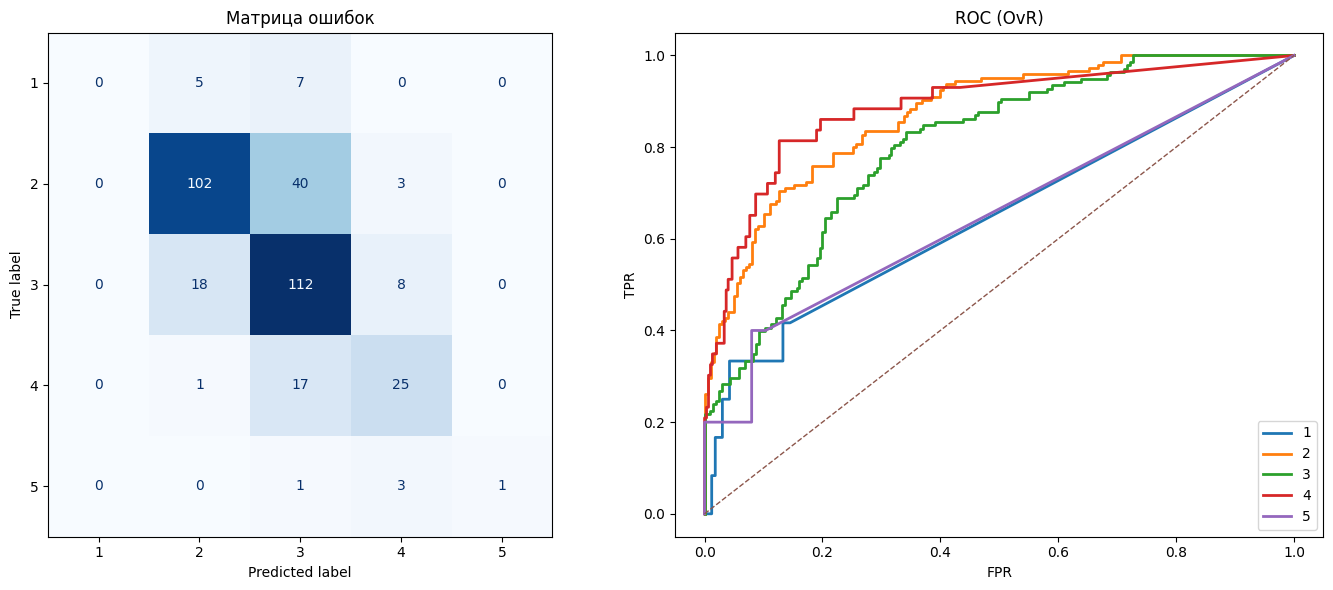

In [ ]:
clf = KNeighborsClassifier(
                n_neighbors=11,
                weights="distance",                         
                metric="chebyshev")  
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

tree_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

Как мы видим метод ближайших соседей показывает хорошую точность. 

# Нейронная сеть

## Обучение модели

In [32]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import LabelEncoder
import datetime
import matplotlib.pyplot as plt
import tempfile
import os

# --- Кодировщик меток (качество вина) ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

print("Классы качества:", le.classes_)
print("num_classes =", num_classes, ", input_dim =", input_dim)

# --- Функция создания модели ---
def create_model(n_hidden=2, units=64, dropout_rate=0.2, learning_rate=1e-3):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- НОВОЕ ЛОГИРОВАНИЕ В TENSORBOARD ---
log_dir = tempfile.mkdtemp(prefix="tb_wine_")
print("Логи TensorBoard будут здесь:", log_dir)

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# --- Обучение базовой модели ---
model = create_model(
    n_hidden=2,
    units=64,
    dropout_rate=0.2,
    learning_rate=1e-3
)

history = model.fit(
    X_train_scaled, y_train_enc,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[tensorboard_cb],
    verbose=1
)

# --- Оценка на тесте ---
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_enc, verbose=0)
print(f"Тестовая точность: {test_acc:.4f}, тестовая ошибка: {test_loss:.4f}")
print("Логи TensorBoard в папке:", log_dir)


Классы качества: [1 2 3 4 5]
num_classes = 5 , input_dim = 11
Логи TensorBoard будут здесь: C:\Users\bulch\AppData\Local\Temp\tb_wine_xos1ftkc
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4563 - loss: 1.3883 - val_accuracy: 0.5063 - val_loss: 1.2250
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5359 - loss: 1.1941 - val_accuracy: 0.5500 - val_loss: 1.1155
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5656 - loss: 1.0971 - val_accuracy: 0.5750 - val_loss: 1.0725
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5703 - loss: 1.0489 - val_accuracy: 0.5625 - val_loss: 1.0505
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5828 - loss: 1.0408 - val_accuracy: 0.5625 - val_loss: 1.0373
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5703 - loss: 1.0074 - val_accuracy: 0.5562 - val_loss: 1.0309
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5922 - loss: 0.9930 - val_accuracy: 

In [38]:
%load_ext tensorboard
%tensorboard --logdir "C:\Users\bulch\AppData\Local\Temp\tb_wine_xos1ftkc"

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6008 (pid 14440), started 0:06:00 ago. (Use '!kill 14440' to kill it.)

эксперименты с гиперпараметрами (несколько запусков)

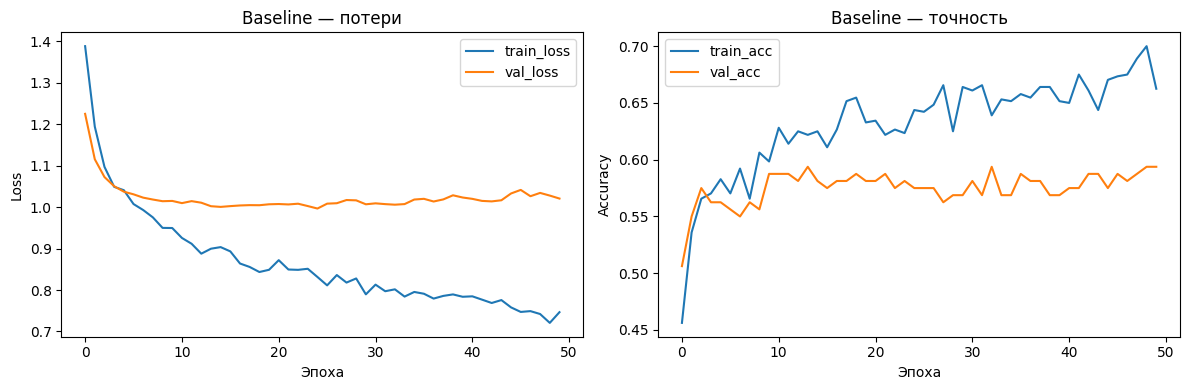

In [37]:
def plot_history(h, title="Базовая модель"):
    plt.figure(figsize=(12,4))

    # Потери
    plt.subplot(1,2,1)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title(title + " — потери")
    plt.legend()

    # Точность
    plt.subplot(1,2,2)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.title(title + " — точность")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history, "Baseline")
